# 03 — Explainability and Reason Codes

Use XGBoost contribution values as SHAP-style additive explanations: global importance from mean absolute contribution, then local reason codes for declined applicants.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..', 'src').resolve()))

import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb

from credit_risk import data, threshold

MODELS_DIR = Path('..', 'models')
FIG_DIR = Path('..', 'reports', 'figures')
TABLE_DIR = Path('..', 'reports', 'tables')
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

raw = data.load_raw()
train_df, test_df = data.train_test_split_data(raw)
feats = data.feature_columns(raw)
X_train, y_train = train_df[feats], train_df[data.TARGET]
X_test, y_test = test_df[feats], test_df[data.TARGET]
protected_test = test_df[list(data.PROTECTED)].copy()

xgb_model = xgb.XGBClassifier()
xgb_model.load_model(MODELS_DIR / 'xgboost_model.json')
score_xgb = xgb_model.predict_proba(X_test)[:, 1]
chosen_threshold = threshold.optimal_threshold(y_test.to_numpy(), score_xgb).best_threshold
print(f'test_rows={len(test_df):,}')
print(f'chosen_threshold={chosen_threshold:.3f}')


test_rows=7,500
chosen_threshold=0.151


  feature  mean_abs_contribution
    PAY_0               0.470604
LIMIT_BAL               0.190771
BILL_AMT1               0.154773
 PAY_AMT2               0.131439
    PAY_2               0.130191
 PAY_AMT1               0.093182
 PAY_AMT3               0.089104
    PAY_3               0.078309
BILL_AMT3               0.074167
 PAY_AMT6               0.073852


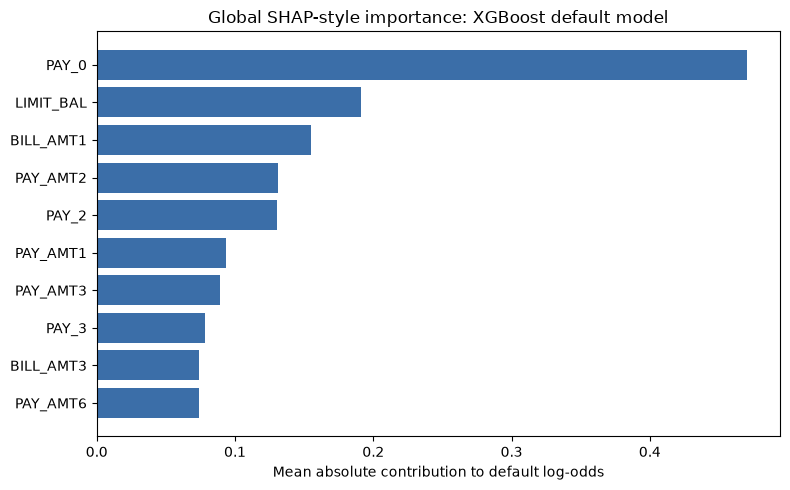

In [2]:
booster = xgb_model.get_booster()
dmatrix = xgb.DMatrix(X_test, feature_names=list(X_test.columns))
contribs = booster.predict(dmatrix, pred_contribs=True)
contrib_df = pd.DataFrame(contribs[:, :-1], columns=X_test.columns, index=X_test.index)

importance = (
    contrib_df.abs().mean()
    .sort_values(ascending=False)
    .rename('mean_abs_contribution')
    .reset_index()
    .rename(columns={'index': 'feature'})
)
importance.to_csv(TABLE_DIR / 'shap_global_importance.csv', index=False)
print(importance.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
top = importance.head(10).iloc[::-1]
ax.barh(top['feature'], top['mean_abs_contribution'], color='#3B6EA8')
ax.set_title('Global SHAP-style importance: XGBoost default model')
ax.set_xlabel('Mean absolute contribution to default log-odds')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_global_importance.png', dpi=160)
plt.show()


## Local reason codes

The examples below are the three highest-risk declined applicants at the cost-based threshold. Positive contributions increase predicted default risk and become reason codes.

In [3]:
FEATURE_LANGUAGE = {
    'LIMIT_BAL': 'Lower credit limit indicates less borrowing capacity buffer.',
    'PAY_0': 'Most recent repayment status shows delinquency or delayed payment.',
    'PAY_2': 'Prior-month repayment status shows delinquency or delayed payment.',
    'PAY_3': 'Three-month repayment status shows delinquency or delayed payment.',
    'PAY_4': 'Four-month repayment status shows delinquency or delayed payment.',
    'PAY_5': 'Five-month repayment status shows delinquency or delayed payment.',
    'PAY_6': 'Six-month repayment status shows delinquency or delayed payment.',
    'BILL_AMT1': 'Recent bill balance is high relative to the portfolio pattern.',
    'BILL_AMT2': 'Prior bill balance is high relative to the portfolio pattern.',
    'BILL_AMT3': 'Older bill balance is high relative to the portfolio pattern.',
    'BILL_AMT4': 'Four-month bill balance adds risk signal.',
    'BILL_AMT5': 'Five-month bill balance adds risk signal.',
    'BILL_AMT6': 'Six-month bill balance adds risk signal.',
    'PAY_AMT1': 'Most recent payment amount is low relative to balance history.',
    'PAY_AMT2': 'Prior payment amount is low relative to balance history.',
    'PAY_AMT3': 'Three-month payment amount is low relative to balance history.',
    'PAY_AMT4': 'Four-month payment amount is low relative to balance history.',
    'PAY_AMT5': 'Five-month payment amount is low relative to balance history.',
    'PAY_AMT6': 'Six-month payment amount is low relative to balance history.',
}

def reason_sentence(feature: str, contribution: float, value: float) -> str:
    base = FEATURE_LANGUAGE.get(feature, f'{feature} adds risk signal.')
    direction = 'increases' if contribution > 0 else 'reduces'
    return f'{base} Observed value: {value:,.0f}; this {direction} model-estimated default risk.'

declined = pd.DataFrame({'score': score_xgb}, index=X_test.index)
declined = declined[declined['score'] >= chosen_threshold].sort_values('score', ascending=False).head(3)
records = []
for example_num, idx in enumerate(declined.index, start=1):
    positive = contrib_df.loc[idx].sort_values(ascending=False).head(4)
    row = {
        'example': example_num,
        'ID': int(test_df.loc[idx, 'ID']),
        'predicted_default_probability': float(score_xgb[list(X_test.index).index(idx)]),
        'decision': 'decline',
    }
    for rank, (feature, contribution) in enumerate(positive.items(), start=1):
        row[f'reason_{rank}_feature'] = feature
        row[f'reason_{rank}_plain_language'] = reason_sentence(feature, contribution, X_test.loc[idx, feature])
        row[f'reason_{rank}_contribution'] = float(contribution)
    records.append(row)

reason_codes = pd.DataFrame(records)
reason_codes.to_csv(TABLE_DIR / 'declined_reason_codes.csv', index=False)
for _, row in reason_codes.iterrows():
    print(f"Applicant ID {int(row['ID'])}: predicted default probability {row['predicted_default_probability']:.1%}; decision={row['decision']}")
    for rank in range(1, 5):
        print(f"  {rank}. {row[f'reason_{rank}_plain_language']}")


Applicant ID 10745: predicted default probability 88.5%; decision=decline
  1. Most recent repayment status shows delinquency or delayed payment. Observed value: 2; this increases model-estimated default risk.
  2. Prior-month repayment status shows delinquency or delayed payment. Observed value: 2; this increases model-estimated default risk.
  3. Recent bill balance is high relative to the portfolio pattern. Observed value: 2,482; this increases model-estimated default risk.
  4. Six-month repayment status shows delinquency or delayed payment. Observed value: 2; this increases model-estimated default risk.
Applicant ID 14951: predicted default probability 88.5%; decision=decline
  1. Most recent repayment status shows delinquency or delayed payment. Observed value: 2; this increases model-estimated default risk.
  2. Prior-month repayment status shows delinquency or delayed payment. Observed value: 2; this increases model-estimated default risk.
  3. Recent bill balance is high relat